**Step 0A**   — (Optional) Mount Google Drive

Mount Drive if you want to **save your trained models** so they persist after the Colab session ends.
Skip this cell if you don't need to save models.

In [1]:
SAVE_MODELS_TO_DRIVE = True  # ← Set to True to enable Drive saving

if SAVE_MODELS_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/cnn_tutorial_models/'
    import os
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f" Drive mounted. Models will be saved to: {SAVE_DIR}")
else:
    SAVE_DIR = '/content/'   # temporary Colab storage
    print("  Drive not mounted. Models saved to temporary Colab storage.")
    print("   They will be lost when the session ends.")

Mounted at /content/drive
 Drive mounted. Models will be saved to: /content/drive/MyDrive/cnn_tutorial_models/


##  Step 0B — Imports

TensorFlow, Keras, and plotting libraries come pre-installed in Colab — no `pip install` needed!

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110   # crisper figures in Colab

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import time, os

# Seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f" TensorFlow : {tf.__version__}")
print(f" Keras      : {keras.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f" GPUs found : {len(gpus)}  →  {'GPU training active' if gpus else 'CPU only'}")

 TensorFlow : 2.20.0
 Keras      : 3.13.2
 GPUs found : 1  →  GPU training active


---
##  Step 1 — Load and Explore the Dataset

In [3]:
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Downloading CIFAR-10 (first run only, ~170 MB)...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("\nDataset loaded!")
print(f"  Training images : {x_train.shape}  → (samples, height, width, channels)")
print(f"  Test images     : {x_test.shape}")
print(f"  Pixel range     : {x_train.min()} – {x_train.max()}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step

Dataset loaded!
  Training images : (50000, 32, 32, 3)  → (samples, height, width, channels)
  Test images     : (10000, 32, 32, 3)
  Pixel range     : 0 – 255


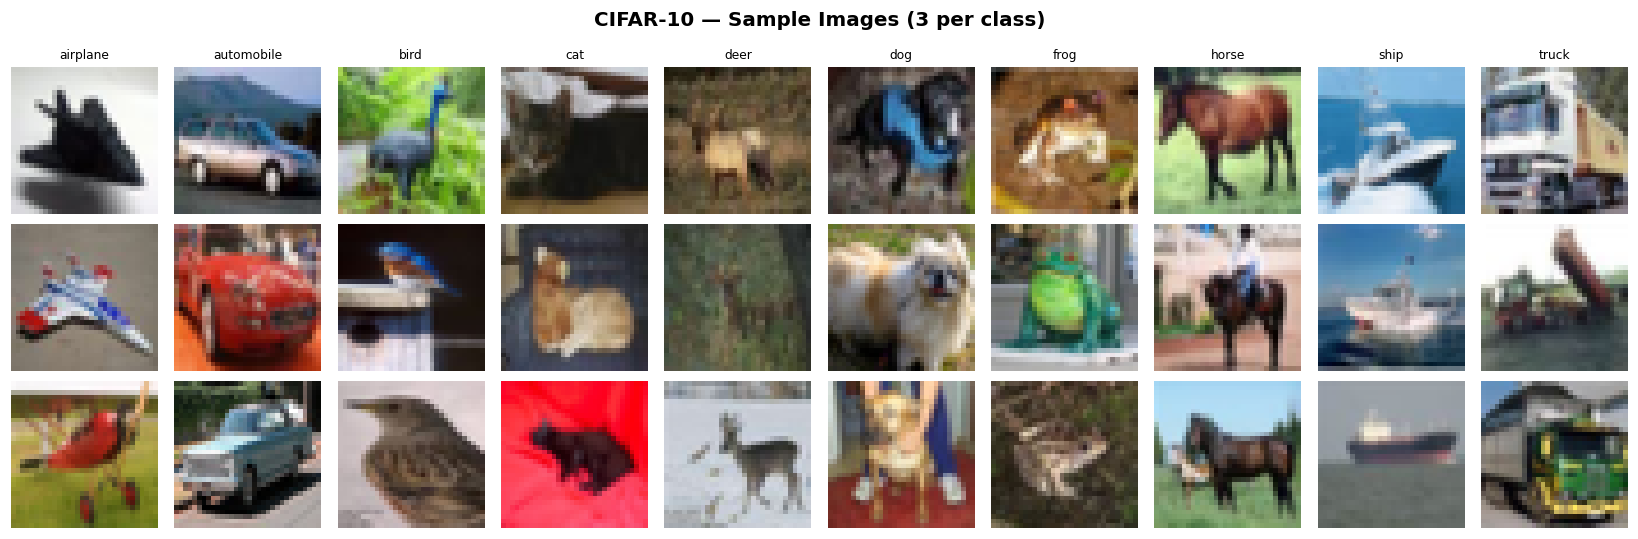

In [4]:
# Show 3 examples of each class
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle('CIFAR-10 — Sample Images (3 per class)', fontsize=13, fontweight='bold')

for class_idx in range(10):
    class_images = x_train[y_train.flatten() == class_idx][:3]
    for row in range(3):
        axes[row, class_idx].imshow(class_images[row])
        axes[row, class_idx].axis('off')
        if row == 0:
            axes[row, class_idx].set_title(CLASS_NAMES[class_idx], fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
# Normalize pixels [0, 255] → [0.0, 1.0]
# Neural networks train much better with small, consistent input values
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten labels (N, 1) → (N,)
y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

print(f" Pixel range after normalization : {x_train_norm.min()} – {x_train_norm.max()}")
print(f" Label shape  : {y_train_flat.shape} | Classes : {np.unique(y_train_flat)}")

 Pixel range after normalization : 0.0 – 1.0
 Label shape  : (50000,) | Classes : [0 1 2 3 4 5 6 7 8 9]


---
## Part 1 — Simple CNN from Scratch

### What is a CNN?
A **Convolutional Neural Network (CNN)** is specially designed for image data. It learns by stacking:

- **`Conv2D`** — detect local patterns: edges → textures → shapes → objects
- **`BatchNormalization`** — stabilise and speed up training
- **`MaxPooling2D`** — shrink spatial size (less memory, more efficient)
- **`Dropout`** — randomly disable neurons to prevent overfitting
- **`Dense`** — final classifier using the learned features

```
Input (32×32×3)
  → [Conv2D → BN → ReLU → MaxPool → Dropout] × 3   ← feature extraction
  → Flatten
  → [Dense → Dropout]                               ← classification
  → Softmax (10 classes)
```

In [6]:
def build_simple_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    Simple CNN built from scratch.

    Block 1: Conv(32)  → BN → ReLU → Pool  → Dropout(0.25)
    Block 2: Conv(64)  → BN → ReLU → Pool  → Dropout(0.25)
    Block 3: Conv(128) → BN → ReLU → Pool  → Dropout(0.25)
    Head   : Flatten → Dense(256) → Dropout(0.5) → Softmax(10)
    """
    model = models.Sequential(name='Simple_CNN')

    # Block 1 ── 32 filters, output: 16×16
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 32×32 → 16×16
    model.add(layers.Dropout(0.25))

    # Block 2 ── 64 filters, output: 8×8
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 16×16 → 8×8
    model.add(layers.Dropout(0.25))

    # Block 3 ── 128 filters, output: 4×4
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 8×8 → 4×4
    model.add(layers.Dropout(0.25))

    # Classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))  # probability per class

    return model


cnn_model = build_simple_cnn()
cnn_model.summary()

Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',  # labels are plain integers
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, verbose=1)
]

print(" Training Simple CNN  (should take ~3–5 min on T4 GPU)...")
t0 = time.time()
cnn_history = cnn_model.fit(
    x_train_norm, y_train_flat,
    validation_split=0.15,
    epochs=5,
    batch_size=64,
    callbacks=callbacks_cnn,
    verbose=1
)
print(f"\n  Training time: {(time.time()-t0)/60:.1f} min")

 Training Simple CNN  (should take ~3–5 min on T4 GPU)...
Epoch 1/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.3771 - loss: 1.7458 - val_accuracy: 0.4628 - val_loss: 1.5357 - learning_rate: 0.0010
Epoch 2/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4964 - loss: 1.4016 - val_accuracy: 0.4649 - val_loss: 1.4953 - learning_rate: 0.0010
Epoch 3/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5587 - loss: 1.2441 - val_accuracy: 0.5861 - val_loss: 1.1132 - learning_rate: 0.0010
Epoch 4/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6062 - loss: 1.1317 - val_accuracy: 0.6325 - val_loss: 1.0881 - learning_rate: 0.0010
Epoch 5/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6310 - loss: 1.0513 - val_accuracy: 0.6475 - val_loss: 0.9971 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

  Training time: 0.7 min


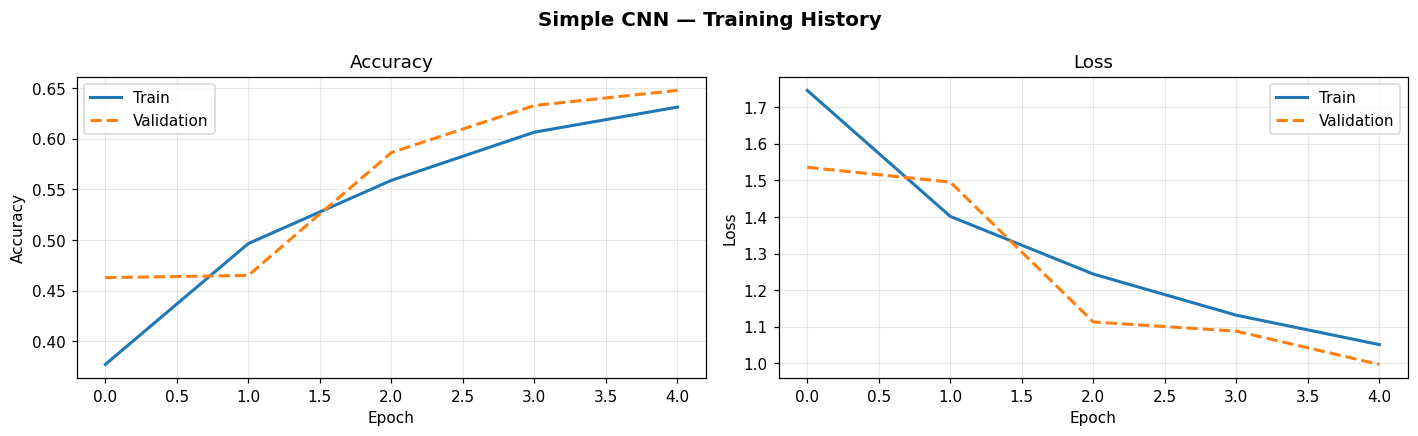


 Simple CNN — Test Accuracy : 63.54%
 Simple CNN — Test Loss     : 1.0264


In [8]:
def plot_history(history, title='Training History'):
    """Plot accuracy and loss curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, metric, ylabel in [
        (ax1, 'accuracy', 'Accuracy'),
        (ax2, 'loss',     'Loss')
    ]:
        ax.plot(history.history[metric],         label='Train',      linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2, linestyle='--')
        ax.set_title(ylabel)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(cnn_history, 'Simple CNN — Training History')

cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test_flat, verbose=0)
print(f"\n Simple CNN — Test Accuracy : {cnn_acc*100:.2f}%")
print(f" Simple CNN — Test Loss     : {cnn_loss:.4f}")

In [9]:
# Save the CNN model (to Drive if mounted, else to /content/)
cnn_save_path = os.path.join(SAVE_DIR, 'simple_cnn.keras')
cnn_model.save(cnn_save_path)
print(f" Model saved → {cnn_save_path}")

 Model saved → /content/drive/MyDrive/cnn_tutorial_models/simple_cnn.keras


---
## 🔬 Part 2 — Pretrained Model (Feature Extraction)

### The Problem with Training from Scratch
Our CNN learned entirely from CIFAR-10's 50,000 training images. But researchers have trained models on **ImageNet** — 14 million images across 1,000 categories. Those models already know what edges, textures, fur, wheels, and wings look like.

### Feature Extraction Strategy
1. **Load** MobileNetV2 pretrained on ImageNet — *without* its top classifier
2. **Freeze** all its weights (don't update them during training)
3. **Add** our own small classification head
4. **Train only** the new head — fast and data-efficient!

```
[MobileNetV2 base — FROZEN] → GlobalAvgPool → Dense(128) → Softmax(10)
                                  ←────────────────────────────────────────
                                       only these layers train
```



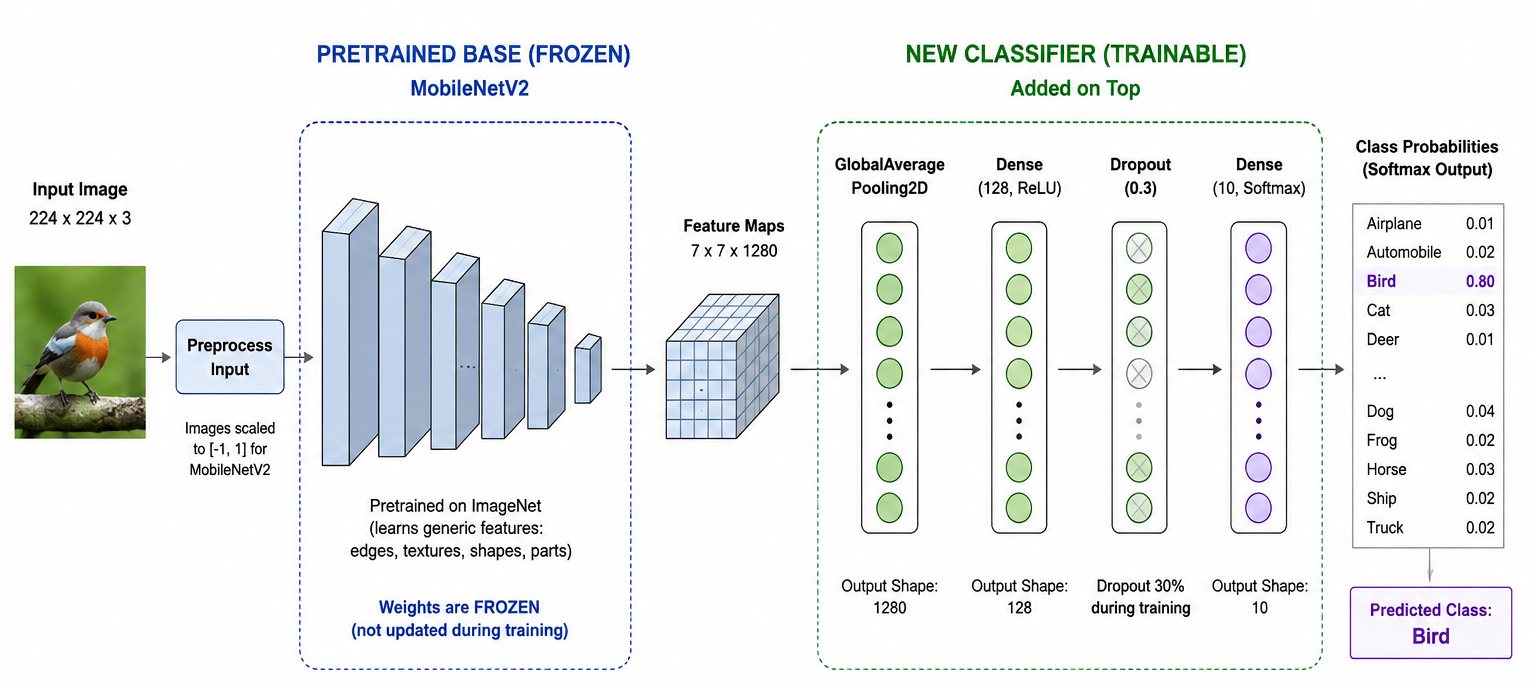

In [10]:
TARGET_SIZE = 96
BATCH_SIZE  = 64
AUTOTUNE    = tf.data.AUTOTUNE

def make_dataset(images, labels, training=True):
    """
    Build a tf.data.Dataset that resizes images lazily (no extra RAM).
    - images : float32 numpy array, values in [0, 1], shape (N, 32, 32, 3)
    - labels : int numpy array, shape (N,)
    - training: if True, shuffle the dataset each epoch
    """
    def resize_fn(image, label):
        image = tf.image.resize(image, [TARGET_SIZE, TARGET_SIZE])
        return image, label

    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(buffer_size=10_000, seed=42)
    ds = (
        ds
        .map(resize_fn, num_parallel_calls=AUTOTUNE)  # resize in parallel
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)                           # overlap GPU+CPU work
    )
    return ds


# Split off 15% for validation (same split as before)
val_split   = int(len(x_train_norm) * 0.15)
x_val,   y_val   = x_train_norm[:val_split],  y_train_flat[:val_split]
x_tr,    y_tr    = x_train_norm[val_split:],   y_train_flat[val_split:]

train_ds = make_dataset(x_tr,          y_tr,       training=True)
val_ds   = make_dataset(x_val,         y_val,       training=False)
test_ds  = make_dataset(x_test_norm,   y_test_flat, training=False)

# Quick check — peek at one batch shape without loading everything
sample_images, sample_labels = next(iter(train_ds))
print(f"  Pipeline ready!")
print(f"   Batch shape : {sample_images.shape}  (images resized to {TARGET_SIZE}×{TARGET_SIZE})")
print(f"   Labels shape: {sample_labels.shape}")
print(f"   Train batches : {len(train_ds)} | Val batches : {len(val_ds)} | Test batches : {len(test_ds)}")
print(f"    Extra RAM used: ~0 MB  (no full array stored)")

  Pipeline ready!
   Batch shape : (64, 96, 96, 3)  (images resized to 96×96)
   Labels shape: (64,)
   Train batches : 665 | Val batches : 118 | Test batches : 157
    Extra RAM used: ~0 MB  (no full array stored)


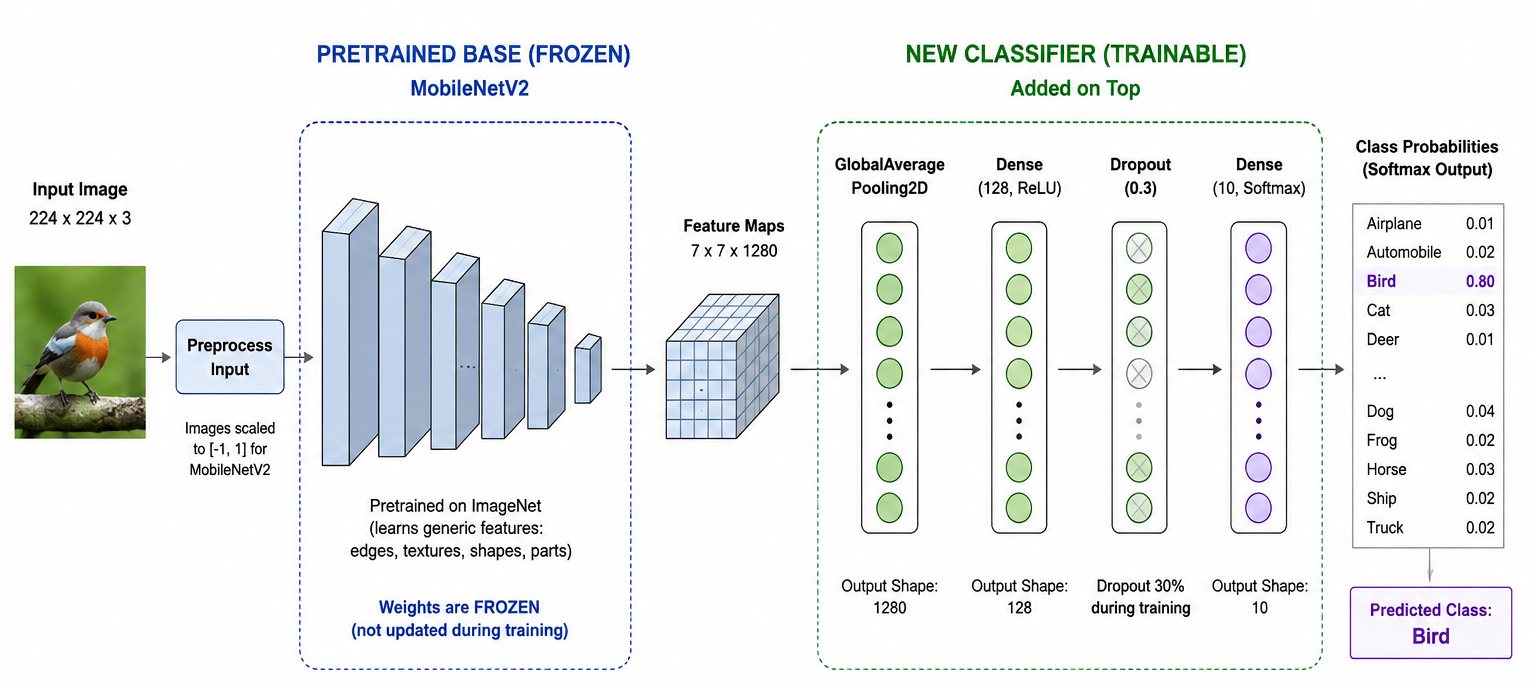

In [11]:
def build_pretrained_model(input_shape=(TARGET_SIZE, TARGET_SIZE, 3), num_classes=10):
    """Feature extraction with frozen MobileNetV2 base."""

    # 1. Load base WITHOUT the ImageNet top classifier
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,     # remove the 1000-class head
        weights='imagenet'     # pretrained weights
    )
    # 2. Freeze — weights will NOT be updated
    base_model.trainable = False

    frozen = sum(not l.trainable for l in base_model.layers)
    print(f"Base: {base_model.name} | Layers: {len(base_model.layers)} | Frozen: {frozen}")

    # 3. Build our model on top
    inputs = keras.Input(shape=input_shape)
    # MobileNetV2 expects pixels in [-1, 1] — the preprocess_input function handles this
    x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
    x = base_model(x, training=False)  # training=False keeps BatchNorm frozen
    x = layers.GlobalAveragePooling2D()(x)  # pool spatial dims → 1D feature vector
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='Pretrained_FeatureExtraction')


pretrained_model = build_pretrained_model()
pretrained_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base: mobilenetv2_1.00_96 | Layers: 154 | Frozen: 154


Model: "Pretrained_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Training Pretrained Model — head only (~2–3 min on T4)...
Epoch 1/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.7978 - loss: 0.6042 - val_accuracy: 0.8480 - val_loss: 0.4329 - learning_rate: 0.0010
Epoch 2/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.8500 - loss: 0.4359 - val_accuracy: 0.8597 - val_loss: 0.3978 - learning_rate: 0.0010
Epoch 3/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8680 - loss: 0.3815 - val_accuracy: 0.8648 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 4/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8791 - loss: 0.3457 - val_accuracy: 0.8711 - val_loss: 0.3821 - learning_rate: 0.0010
Epoch 5/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8901 - loss: 0.3160 - val_accuracy: 0.8679 - val_loss: 0.4004 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.

  Training time: 2.4 min


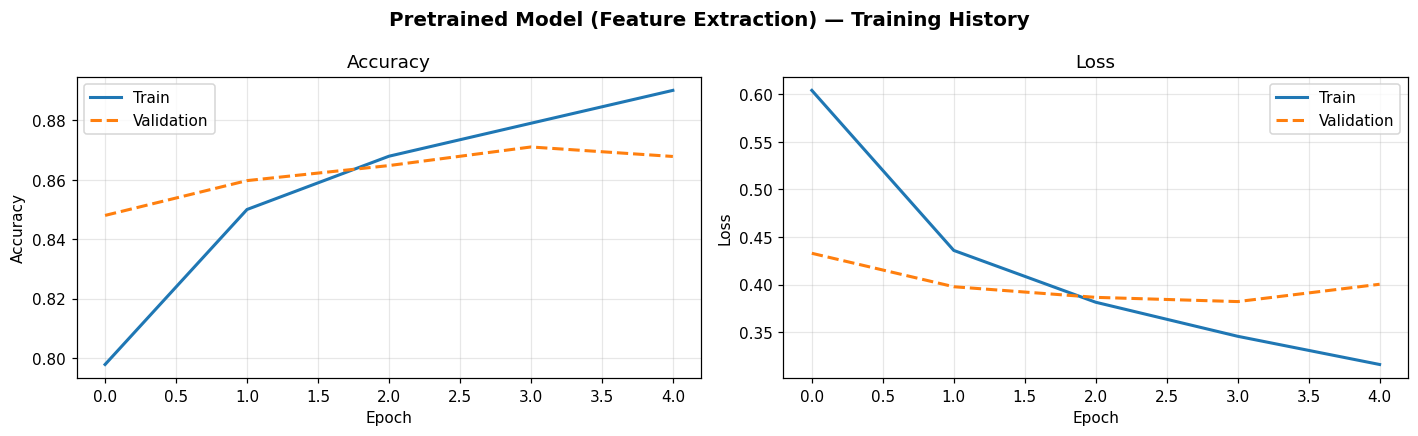


 Pretrained Model — Test Accuracy : 86.55%
 Pretrained Model — Test Loss     : 0.3942


In [12]:
pretrained_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_pt = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, verbose=1)
]

print(" Training Pretrained Model — head only (~2–3 min on T4)...")
t0 = time.time()
pretrained_history = pretrained_model.fit(
    train_ds,              # ← tf.data pipeline (memory-safe)
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks_pt,
    verbose=1
)
print(f"\n  Training time: {(time.time()-t0)/60:.1f} min")

plot_history(pretrained_history, 'Pretrained Model (Feature Extraction) — Training History')

pt_loss, pt_acc = pretrained_model.evaluate(test_ds, verbose=0)
print(f"\n Pretrained Model — Test Accuracy : {pt_acc*100:.2f}%")
print(f" Pretrained Model — Test Loss     : {pt_loss:.4f}")

In [13]:
pt_save_path = os.path.join(SAVE_DIR, 'pretrained_feature_extraction.keras')
pretrained_model.save(pt_save_path)
print(f" Model saved → {pt_save_path}")

 Model saved → /content/drive/MyDrive/cnn_tutorial_models/pretrained_feature_extraction.keras
